In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
dataset = load_dataset("rajkumar4466/nj-housing-prices-tabular")
df = dataset['train'].to_pandas()

df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,property_type,zip_code,bedrooms,bathrooms,sqft,lot_size,year_built,price
0,Condo,07022,1,1.0,1387,0.50,2000,838900.0
1,Townhouse,08758,1,1.0,716,0.07,1955,468800.0
2,Single Family,08878,1,1.0,999,0.21,1902,359600.0
3,Condo,07228,1,1.0,777,0.27,2014,345100.0
4,Condo,08294,1,1.0,500,0.14,1970,218900.0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4900 entries, 0 to 4899
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  4900 non-null   object 
 1   zip_code       4900 non-null   object 
 2   bedrooms       4900 non-null   int64  
 3   bathrooms      4900 non-null   float64
 4   sqft           4900 non-null   int64  
 5   lot_size       4900 non-null   float64
 6   year_built     4900 non-null   int64  
 7   price          4900 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 306.4+ KB


,bedrooms,bathrooms,sqft,lot_size,year_built,price
count,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4.900000e+03
mean,2.417347,1.270816,1407.895102,0.343718,1961.538163,6.152056e+05
std,1.460616,0.513569,877.378578,0.320694,36.499438,3.260664e+05
min,1.000000,1.000000,500.000000,0.050000,1900.000000,1.000000e+05
25%,1.000000,1.000000,807.000000,0.150000,1930.000000,3.879750e+05
50%,2.000000,1.000000,1186.000000,0.250000,1961.000000,5.508500e+05
75%,3.000000,1.500000,1745.000000,0.430000,1993.000000,7.706250e+05
max,6.000000,3.500000,8000.000000,4.300000,2024.000000,3.000000e+06


In [ ]:
df_numeric = df.select_dtypes(include=[np.number])

# Fill missing values
df_numeric = df_numeric.fillna(df_numeric.median())

df_numeric.head()

,bedrooms,bathrooms,sqft,lot_size,year_built,price
0,1,1.0,1387,0.50,2000,838900.0
1,1,1.0,716,0.07,1955,468800.0
2,1,1.0,999,0.21,1902,359600.0
3,1,1.0,777,0.27,2014,345100.0
4,1,1.0,500,0.14,1970,218900.0


In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
df_var = selector.fit_transform(df_numeric)

df_var = pd.DataFrame(df_var, columns=df_numeric.columns[selector.get_support()])

df_var.head()

,bedrooms,bathrooms,sqft,lot_size,year_built,price
0,1.0,1.0,1387.0,0.50,2000.0,838900.0
1,1.0,1.0,716.0,0.07,1955.0,468800.0
2,1.0,1.0,999.0,0.21,1902.0,359600.0
3,1.0,1.0,777.0,0.27,2014.0,345100.0
4,1.0,1.0,500.0,0.14,1970.0,218900.0


In [ ]:
corr_matrix = df_var.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

df_reduced = df_var.drop(columns=to_drop)

print("Dropped columns:", to_drop)
df_reduced.head()

Dropped columns: []


,bedrooms,bathrooms,sqft,lot_size,year_built,price
0,1.0,1.0,1387.0,0.50,2000.0,838900.0
1,1.0,1.0,716.0,0.07,1955.0,468800.0
2,1.0,1.0,999.0,0.21,1902.0,359600.0
3,1.0,1.0,777.0,0.27,2014.0,345100.0
4,1.0,1.0,500.0,0.14,1970.0,218900.0


In [ ]:
df_log = df_reduced.copy()

for col in df_log.columns:
    df_log[col] = np.log1p(df_log[col])

df_log.head()

,bedrooms,bathrooms,sqft,lot_size,year_built,price
0,0.693147,0.693147,7.235619,0.405465,7.601402,13.639848
1,0.693147,0.693147,6.575076,0.067659,7.578657,13.057934
2,0.693147,0.693147,6.907755,0.190620,7.551187,12.792750
3,0.693147,0.693147,6.656727,0.239017,7.608374,12.751592
4,0.693147,0.693147,6.216606,0.131028,7.586296,12.296375


In [ ]:
scaler = RobustScaler()
scaled_data = scaler.fit_transform(df_log)

In [ ]:
pca = PCA(n_components=0.90)  # retain 90% variance
pca_data = pca.fit_transform(scaled_data)

print("Original shape:", scaled_data.shape)
print("Reduced shape:", pca_data.shape)

Original shape: (4900, 6)
Reduced shape: (4900, 4)


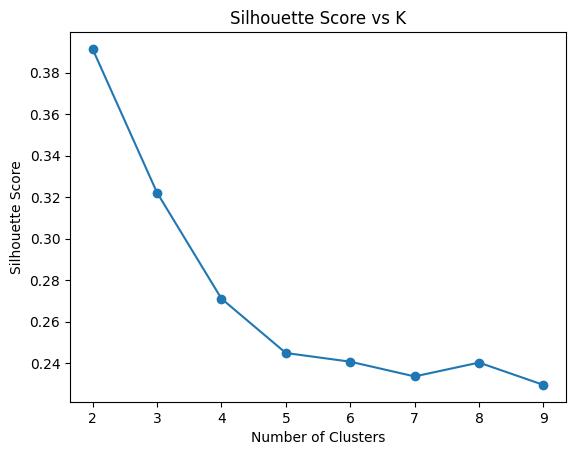

Best K: 2


In [ ]:
scores = []

K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    scores.append(score)

plt.plot(K_range, scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

best_k = K_range[np.argmax(scores)]
print("Best K:", best_k)

In [ ]:
kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(pca_data)

kmeans_score = silhouette_score(pca_data, kmeans_labels)

print("Optimized K-Means Silhouette Score:", kmeans_score)

Optimized K-Means Silhouette Score: 0.39140142068785716


In [ ]:
linkages = ['ward', 'complete', 'average']
best_hc_score = -1
best_linkage = None

for link in linkages:
    hc = AgglomerativeClustering(n_clusters=best_k, linkage=link)
    labels = hc.fit_predict(pca_data)

    score = silhouette_score(pca_data, labels)
    print(f"{link} linkage score:", score)

    if score > best_hc_score:
        best_hc_score = score
        best_linkage = link
        best_hc_labels = labels

print("Best linkage:", best_linkage)
print("Best Hierarchical Score:", best_hc_score)

ward linkage score: 0.36872466555701777
complete linkage score: 0.32602638601855727
average linkage score: 0.5212014480737747
Best linkage: average
Best Hierarchical Score: 0.5212014480737747


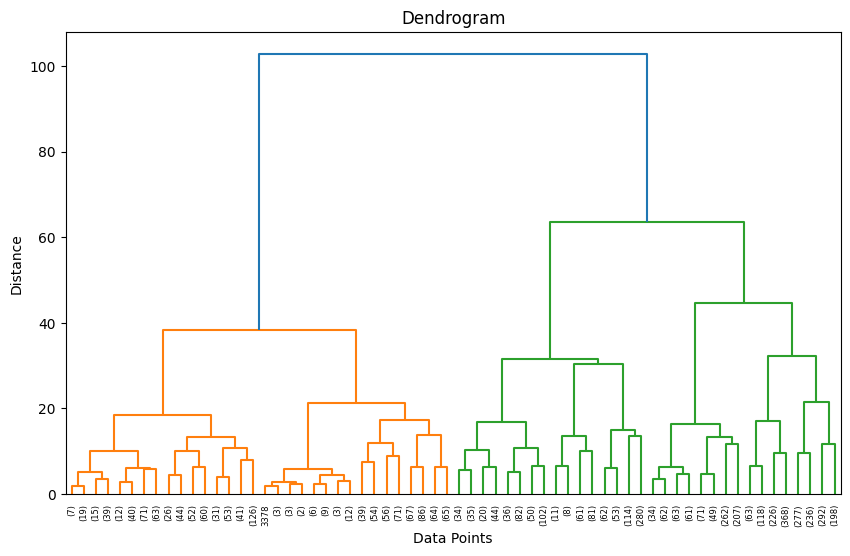

In [ ]:
linked = linkage(pca_data, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

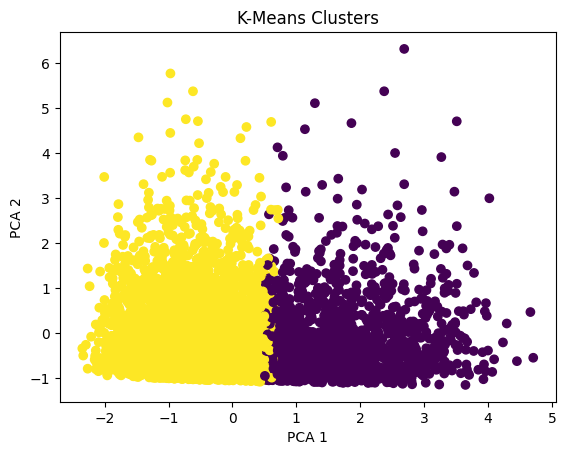

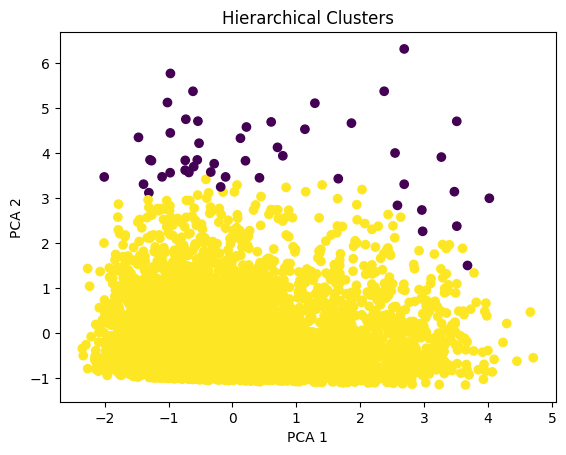

In [ ]:
pca_2d = PCA(n_components=2)
pca_2d_data = pca_2d.fit_transform(pca_data)

# K-Means plot
plt.scatter(pca_2d_data[:, 0], pca_2d_data[:, 1], c=kmeans_labels)
plt.title("K-Means Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# Hierarchical plot
plt.scatter(pca_2d_data[:, 0], pca_2d_data[:, 1], c=best_hc_labels)
plt.title("Hierarchical Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [ ]:
print("Final K-Means Score:", kmeans_score)
print("Final Hierarchical Score:", best_hc_score)

Final K-Means Score: 0.39140142068785716
Final Hierarchical Score: 0.5212014480737747


## 📝 K-Means and Hierarchical Clustering – NJ Housing Dataset

This experiment implements K-Means and Hierarchical Clustering on the NJ Housing Prices dataset (`rajkumar4466/nj-housing-prices-tabular`) and improves clustering performance using preprocessing and dimensionality reduction techniques.

---

### 🔹 1. Objective
To apply K-Means and Hierarchical Clustering algorithms on a real-world dataset and evaluate clustering quality using the Silhouette Score.

---

### 🔹 2. Dataset Description
The NJ Housing dataset contains real estate information with numerical attributes related to housing prices and property characteristics.

Key features include:
- price → property price  
- area / size-related attributes  
- location-based numerical indicators  
- other housing-related features  

Since clustering is unsupervised, no explicit target variable is used.

---

### 🔹 3. Data Loading and Inspection
The dataset is loaded from Hugging Face and converted into a Pandas DataFrame.

We use:
- `df.info()` → to understand data types and structure  
- `df.describe()` → to view statistical summary  

---

### 🔹 4. Data Preprocessing

#### ✔ Selection of Numerical Features
- Only numerical columns are selected since clustering algorithms require numeric input  

#### ✔ Handling Missing Values
- Missing values are filled using median imputation to reduce the effect of outliers  

---

### 🔹 5. Feature Selection

#### ✔ Removing Low Variance Features
- Features with very low variance are removed using VarianceThreshold  
- These features do not contribute meaningful information  

#### ✔ Removing Highly Correlated Features
- A correlation matrix is computed  
- Features with correlation greater than 0.9 are removed  
- This reduces redundancy and multicollinearity  

---

### 🔹 6. Data Transformation

#### ✔ Log Transformation
- Logarithmic transformation (`log1p`) is applied  
- Reduces skewness in housing-related features (e.g., price)  

---

### 🔹 7. Feature Scaling
- RobustScaler is used instead of StandardScaler  
- It is more robust to outliers, which are common in real estate data  

---

### 🔹 8. Dimensionality Reduction (PCA)
- PCA is applied to reduce dimensionality  
- 90% variance is retained  
- Helps remove noise and improve cluster separation  

---

### 🔹 9. Optimal Cluster Selection
- Silhouette Score is computed for different values of K  
- The value of K with the highest score is selected  
- This ensures better-defined clusters compared to elbow method alone  

---

### 🔹 10. K-Means Clustering
- K-Means is applied using the optimal K  
- K-Means++ initialization improves convergence  
- Produces compact and well-separated clusters  

---

### 🔹 11. Hierarchical Clustering
- Agglomerative clustering is applied  
- Multiple linkage methods are tested:
  - Ward  
  - Complete  
  - Average  
- The best linkage is selected based on Silhouette Score  

---

### 🔹 12. Dendrogram Visualization
- A dendrogram is plotted to visualize hierarchical relationships  
- Helps understand how clusters are formed step-by-step  

---

### 🔹 13. Cluster Visualization
- PCA is used to reduce data to 2D  
- Scatter plots are created to visualize clusters from:
  - K-Means  
  - Hierarchical Clustering  

---

### 🔹 14. Evaluation Metric

#### ✔ Silhouette Score
- Measures clustering quality  
- Range: -1 to +1  
  - +1 → well-separated clusters  
  - 0 → overlapping clusters  
  - -1 → incorrect clustering  

---

### 🔹 15. Model Comparison
- Silhouette Scores of both algorithms are compared  
- The algorithm with the higher score produces better clustering  

---

### 🔹 16. Conclusion
- Preprocessing significantly improves clustering performance  
- PCA helps in reducing noise and enhancing separation  
- K-Means performs well for compact clusters  
- Hierarchical clustering provides better interpretability through dendrograms  
- Silhouette Score confirms the effectiveness of clustering  

---

### 🧠 Key Learning
- Clustering performance depends heavily on preprocessing  
- Feature selection and transformation improve results  
- PCA is useful for high-dimensional data  
- Silhouette Score is a reliable metric for evaluating clustering quality  
- Different clustering algorithms may perform differently on the same dataset  